<a href="https://colab.research.google.com/github/Almat-nag/deep-learning-final-project/blob/master/notebooks/week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Week 2: Text Preprocessing and Baseline Model
# Project: Automated Detection of Cyberbullying and Toxic Behavior
# Dataset: m375zhan/modified_jigsaw_toxic_comment_classification_challenge

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# 1. Load dataset from Hugging Face
dataset = load_dataset("m375zhan/modified_jigsaw_toxic_comment_classification_challenge")

print(dataset)

# Convert Hugging Face dataset to pandas DataFrame
df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
})
Dataset shape: (159571, 8)
                 id                                               text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0    

In [5]:
# 2. Define text column and target labels
# ------------------------------------------------------------

TEXT_COLUMN = "text"

target_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

In [7]:
# 3. Check missing values
# ------------------------------------------------------------

required_columns = [TEXT_COLUMN] + target_columns

print("\nMissing values:")
print(df[required_columns].isnull().sum())

# Remove rows with missing text
df = df.dropna(subset=[TEXT_COLUMN])

print("\nDataset shape after dropping missing text:", df.shape)


Missing values:
text             0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Dataset shape after dropping missing text: (159571, 8)


In [8]:
# 4. Text preprocessing
# ------------------------------------------------------------

def clean_text(text):
    """
    Clean raw user comment text.
    Steps:
    1. Convert text to lowercase
    2. Remove URLs
    3. Remove numbers and punctuation
    4. Remove extra spaces
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

print("\nOriginal text example:")
print(df[TEXT_COLUMN].iloc[0])

print("\nCleaned text example:")
print(df["clean_text"].iloc[0])


Original text example:
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

Cleaned text example:
explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the template from the talk page since i m retired now



Text length statistics:
count    159571.000000
mean         67.648815
std         100.357877
min           0.000000
25%          16.000000
50%          36.000000
75%          76.000000
max        1403.000000
Name: text_length, dtype: float64

Label distribution:
toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


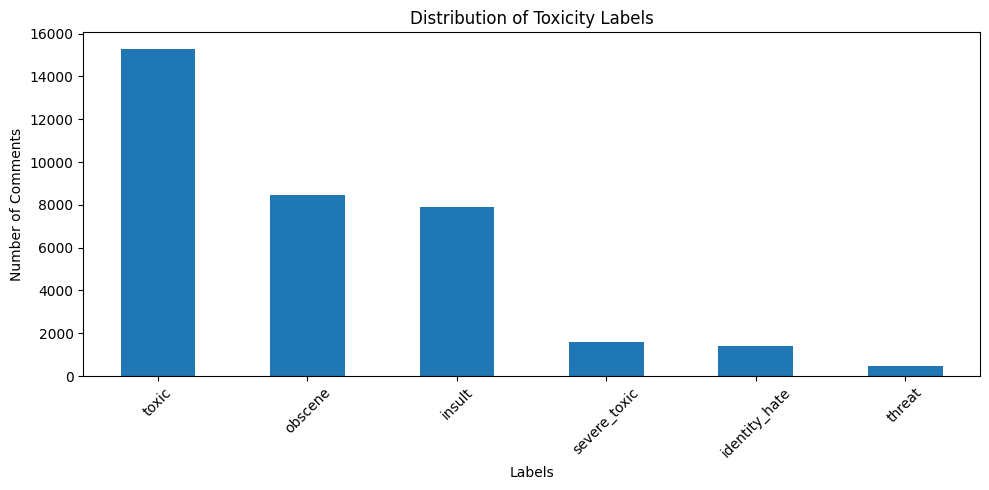

In [9]:
# ------------------------------------------------------------
# 5. Basic EDA for Week 2
# ------------------------------------------------------------

df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

print("\nText length statistics:")
print(df["text_length"].describe())

print("\nLabel distribution:")
print(df[target_columns].sum().sort_values(ascending=False))

# Plot label distribution
label_counts = df[target_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Distribution of Toxicity Labels")
plt.xlabel("Labels")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------------------
# 6. Prepare X and y
# ------------------------------------------------------------

X = df["clean_text"]
y = df[target_columns]

In [11]:
# ------------------------------------------------------------
# 7. Train / Validation / Test Split
# ------------------------------------------------------------

# 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# temporary 20% -> 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("\nData split:")
print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])


Data split:
Train size: 127656
Validation size: 15957
Test size: 15958


In [12]:
# ------------------------------------------------------------
# 8. TF-IDF Vectorization
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF shapes:")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)



TF-IDF shapes:
Train: (127656, 50000)
Validation: (15957, 50000)
Test: (15958, 50000)


In [13]:
# 9. Baseline Model: TF-IDF + Naive Bayes
# ------------------------------------------------------------

baseline_model = MultiOutputClassifier(MultinomialNB())

baseline_model.fit(X_train_tfidf, y_train)

print("\nBaseline model training completed.")


Baseline model training completed.


In [14]:
# ------------------------------------------------------------
# 10. Validation Predictions

y_val_pred = baseline_model.predict(X_val_tfidf)

# predict_proba gives a list of arrays, one array for each label
y_val_proba_list = baseline_model.predict_proba(X_val_tfidf)

# Convert probabilities to matrix: shape = number of samples x number of labels
y_val_proba = np.array([proba[:, 1] for proba in y_val_proba_list]).T

print("Prediction shape:", y_val_pred.shape)
print("Probability shape:", y_val_proba.shape)


Prediction shape: (15957, 6)
Probability shape: (15957, 6)


In [15]:
# 11. Evaluation Function

def evaluate_model(y_true, y_pred, y_proba, labels):
    results = []

    for i, label in enumerate(labels):
        roc_auc = roc_auc_score(y_true[label], y_proba[:, i])
        precision = precision_score(y_true[label], y_pred[:, i], zero_division=0)
        recall = recall_score(y_true[label], y_pred[:, i], zero_division=0)
        f1 = f1_score(y_true[label], y_pred[:, i], zero_division=0)
        accuracy = accuracy_score(y_true[label], y_pred[:, i])

        results.append({
            "label": label,
            "roc_auc": round(roc_auc, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "accuracy": round(accuracy, 4)
        })

    return pd.DataFrame(results)


In [16]:
# 12. Validation Results

validation_results = evaluate_model(
    y_true=y_val,
    y_pred=y_val_pred,
    y_proba=y_val_proba,
    labels=target_columns
)

print("\nValidation Results:")
print(validation_results)

# Average metrics
print("\nAverage Results:")
print(validation_results[["roc_auc", "precision", "recall", "f1_score", "accuracy"]].mean())


Validation Results:
           label  roc_auc  precision  recall  f1_score  accuracy
0          toxic   0.9441     0.9513  0.4193    0.5820    0.9420
1   severe_toxic   0.9401     0.2857  0.0126    0.0241    0.9898
2        obscene   0.9450     0.9577  0.3690    0.5328    0.9652
3         threat   0.8438     0.0000  0.0000    0.0000    0.9977
4         insult   0.9350     0.8649  0.2779    0.4207    0.9613
5  identity_hate   0.8801     1.0000  0.0064    0.0127    0.9903

Average Results:
roc_auc      0.914683
precision    0.676600
recall       0.180867
f1_score     0.262050
accuracy     0.974383
dtype: float64


In [17]:
# 13. Save Results

import os

os.makedirs("results", exist_ok=True)

validation_results.to_csv("results/week2_baseline_validation_results.csv", index=False)

print("\nResults saved to: results/week2_baseline_validation_results.csv")


Results saved to: results/week2_baseline_validation_results.csv
